In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import math

In [2]:
df = pd.read_csv("data/synthetic_bank_churn_50000.csv")

=== 1. THÔNG TIN DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CreditScore                50000 non-null  float64
 1   Geography                  50000 non-null  str    
 2   Gender                     50000 non-null  str    
 3   Age                        50000 non-null  float64
 4   Tenure                     50000 non-null  float64
 5   Balance                    50000 non-null  float64
 6   NumOfProducts              50000 non-null  int64  
 7   HasCrCard                  50000 non-null  int64  
 8   IsActiveMember             50000 non-null  int64  
 9   EstimatedSalary            50000 non-null  float64
 10  Exited                     50000 non-null  int64  
 11  login_count_last_30d       50000 non-null  int64  
 12  num_transactions_last_90d  50000 non-null  int64  
 13  avg_transaction_amount     5

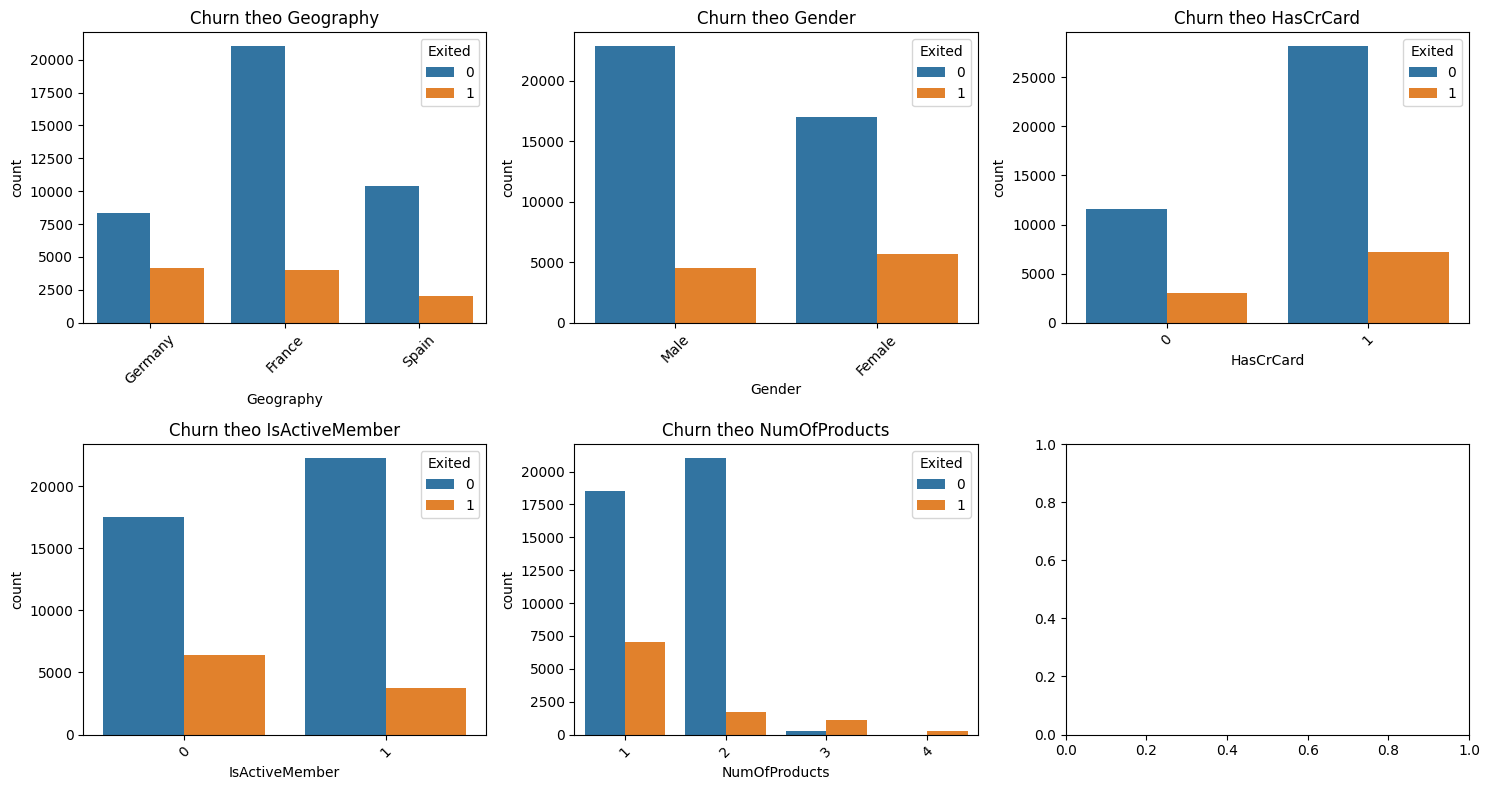

In [3]:
# ====================== 2. EDA (ĐÃ TỐI ƯU - PRO VERSION) ======================
print("=== 1. THÔNG TIN DATASET ===")
print(df.info())
print("\n=== 2. THỐNG KÊ MÔ TẢ ===")
print(df.describe())

print("\n=== 3. PHÂN PHỐI TARGET (Churn) ===")
print(df['Exited'].value_counts(normalize=True))

# === MISSING VALUES ===
print("\n=== 4. KIỂM TRA MISSING VALUES ===")
print(df.isnull().sum().sort_values(ascending=False))

# === CATEGORICAL ANALYSIS ===
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
print("\n=== 5. CHURN RATE THEO CÁC BIẾN PHÂN LOẠI ===")
for col in cat_cols:
    churn_rate = df.groupby(col)['Exited'].mean().round(3)
    print(f"\nChurn rate theo {col}:")
    print(churn_rate)

# Trực quan hóa categorical
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Exited', data=df, ax=axes[i])
    axes[i].set_title(f"Churn theo {col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


=== 6. PHÂN PHỐI CÁC BIẾN SỐ (Histogram + KDE) ===


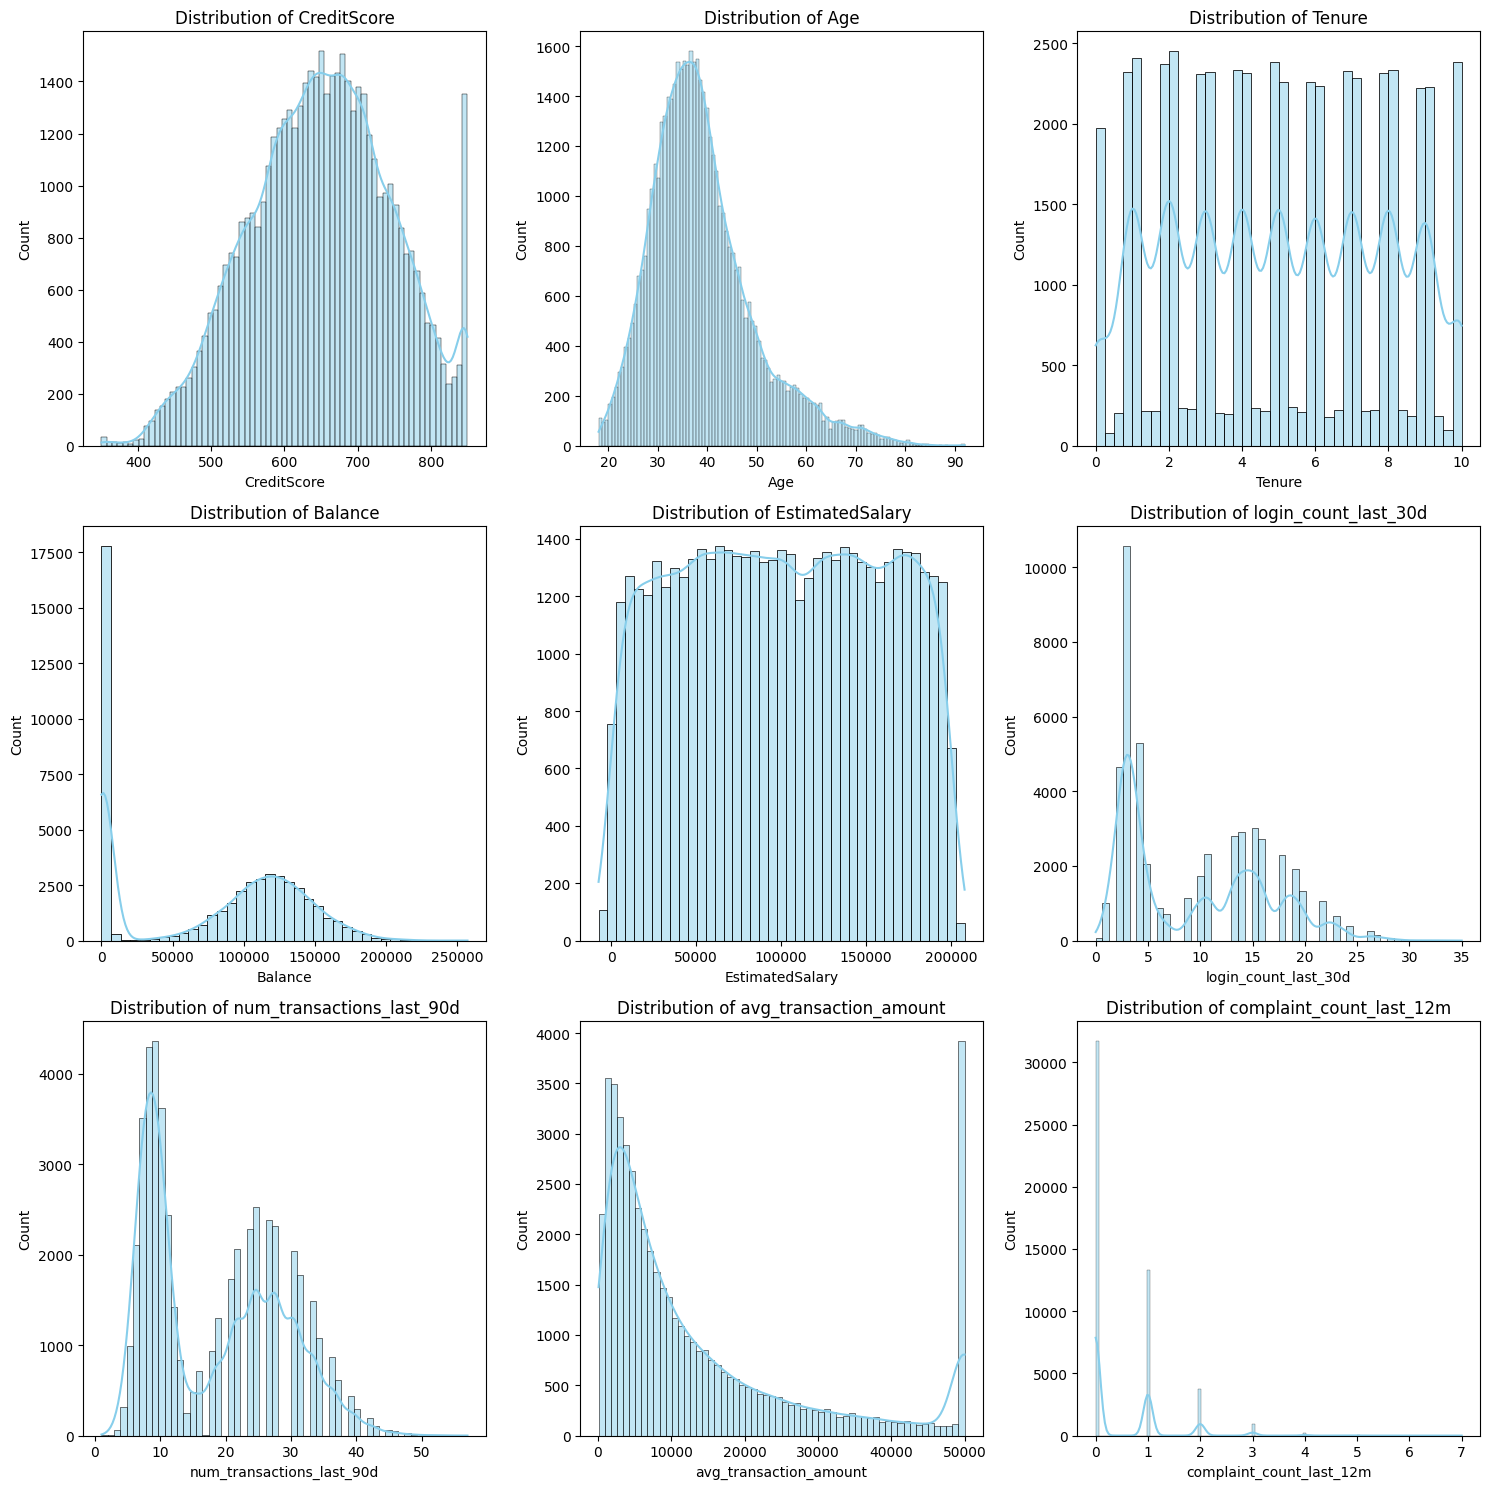

In [4]:
# Các cột numeric thực tế trong dataset
num_cols = [

    'CreditScore', 'Age', 'Tenure', 'Balance',
    'EstimatedSalary', 'login_count_last_30d',
    'num_transactions_last_90d', 'avg_transaction_amount',
    'complaint_count_last_12m'
]

print("\n=== 6. PHÂN PHỐI CÁC BIẾN SỐ (Histogram + KDE) ===")

rows = math.ceil(len(num_cols)/3)
fig, axes = plt.subplots(rows, 3, figsize=(15, 5*rows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribution of {col}")

# Ẩn subplot thừa
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



=== 7. BOXPLOT CÁC BIẾN SỐ THEO CHURN ===


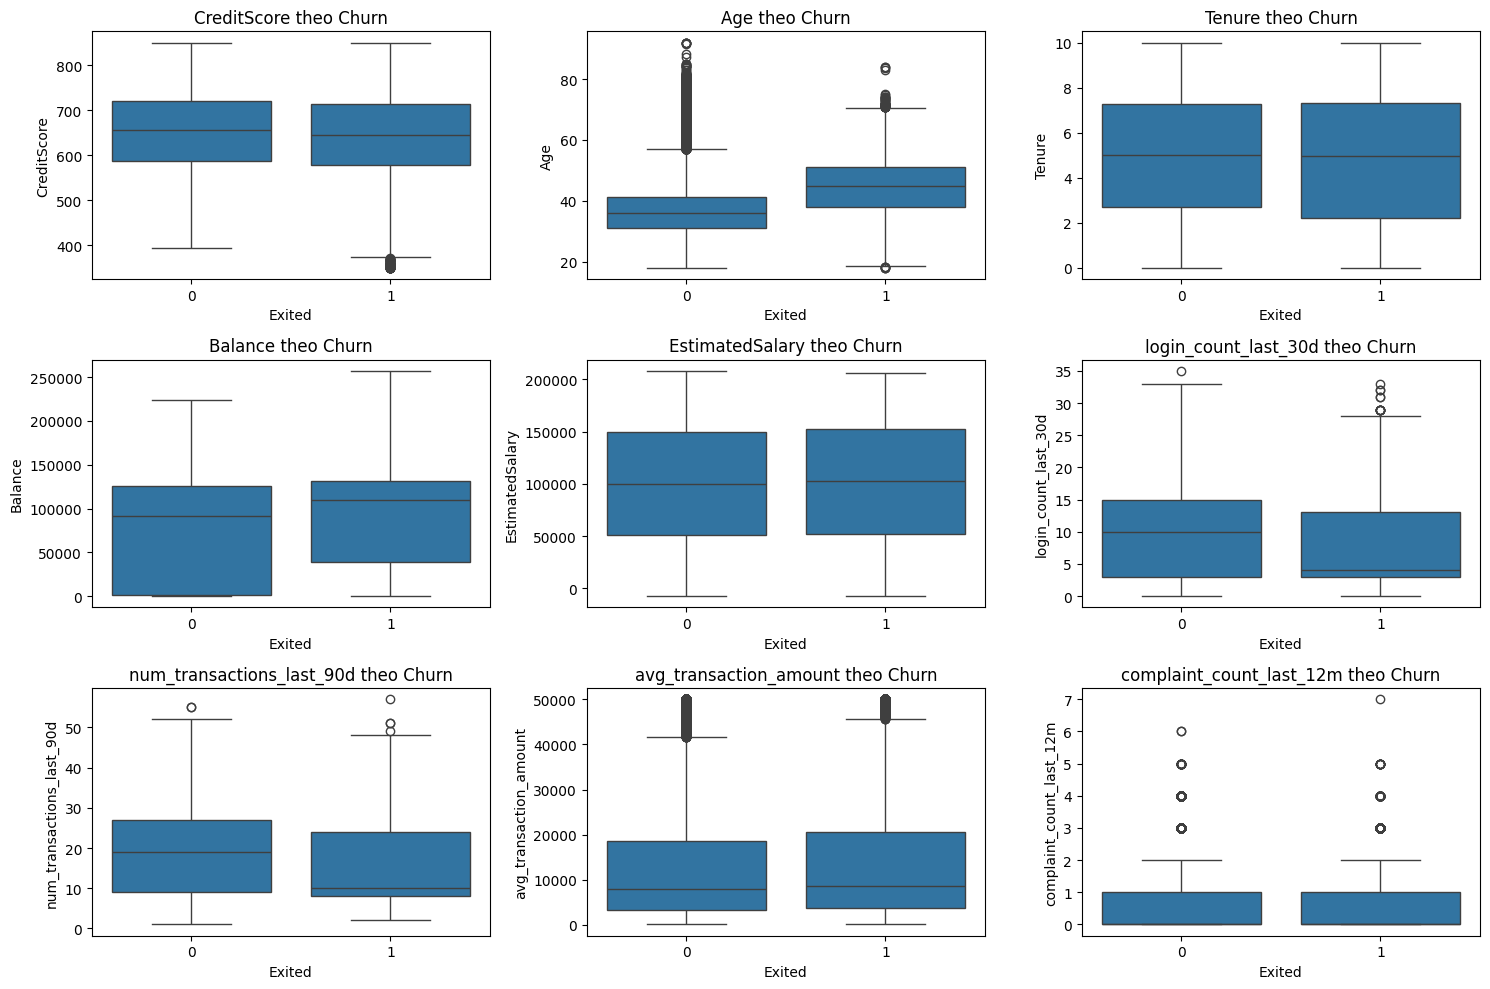


=== 8. MA TRẬN TƯƠNG QUAN (Full) ===


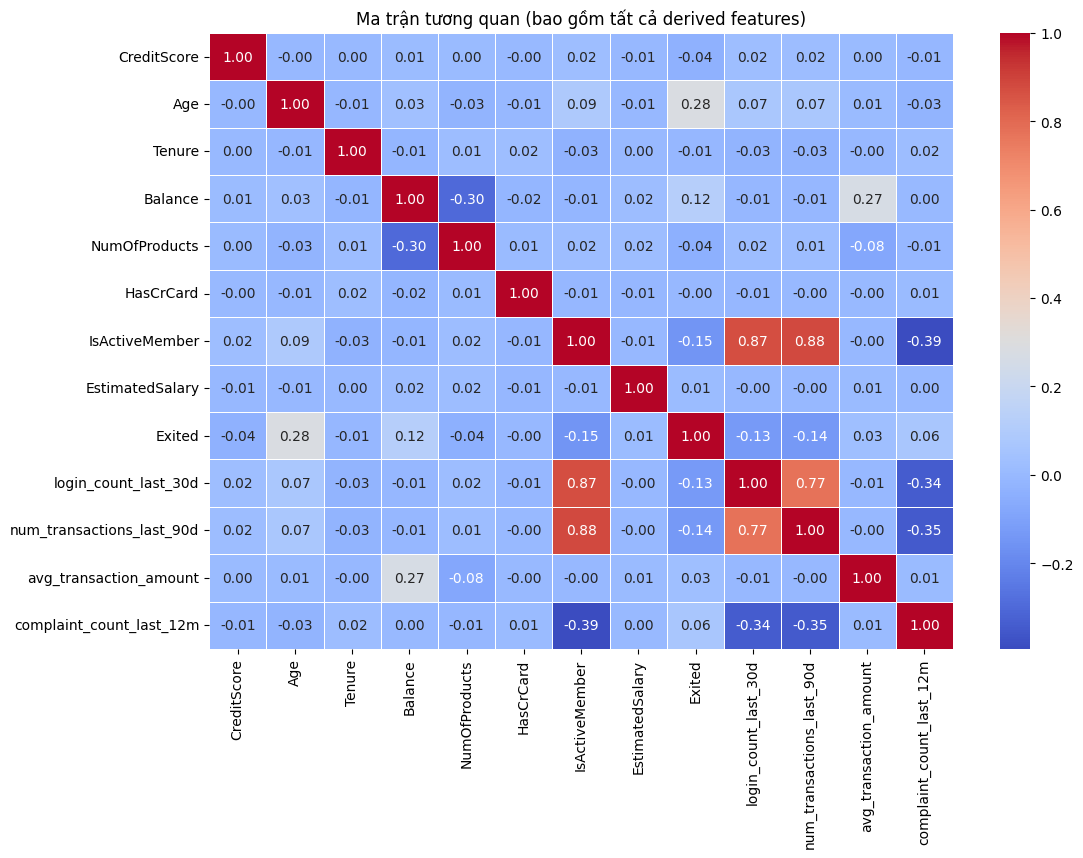

In [5]:
# === RELATIONSHIP WITH TARGET ===
print("\n=== 7. BOXPLOT CÁC BIẾN SỐ THEO CHURN ===")
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Exited', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} theo Churn")
plt.tight_layout()
plt.show()

# === CORRELATION HEATMAP (bao gồm derived) ===
print("\n=== 8. MA TRẬN TƯƠNG QUAN (Full) ===")
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Ma trận tương quan (bao gồm tất cả derived features)")
plt.show()

In [6]:
# ====================== 1. FEATURE ENGINEERING ======================
df['AVG_BALANCE_3M'] = df['Balance'] * (1 + df['IsActiveMember'] * np.random.uniform(-0.02, 0.03, len(df)))
df['MAX_TRANSACTION_6M'] = (df['EstimatedSalary'] * np.random.uniform(0.01, 0.1, len(df))) * (1 + df['NumOfProducts'] * 0.1)
df['STDDEV_TRANSACTION_12M'] = df['MAX_TRANSACTION_6M'] * (np.random.uniform(0.1, 0.3, len(df)) + (1 - df['Age']/df['Age'].max()) * 0.2)

print("✅ Dataset đã load và tạo biến phái sinh xong!")


✅ Dataset đã load và tạo biến phái sinh xong!


In [7]:
# ====================== 2. CHUẨN BỊ DỮ LIỆU ======================
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Xử lý imbalance cho XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Phân loại biến
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()
# Chọn số feature sau khi OneHot + SelectKBest
n_cat_unique = sum(len(df[col].unique()) for col in cat_features)
total_features_after = len(num_features) + n_cat_unique
k_selected = max(10, int(total_features_after * 0.65))

# Preprocessing
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

In [8]:
# ====================== 3. MÔ HÌNH + GRIDSEARCH ======================
model_configs = {
    "RandomForest": {
        "classifier": RandomForestClassifier(random_state=42, class_weight='balanced'),
        "param_grid": {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20],
            'classifier__min_samples_split': [2, 5]
        }
    },
    "LogisticRegression": {
        "classifier": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        "param_grid": {
            'classifier__C': [0.1, 1.0, 10],
            'classifier__penalty': ['l2']
        }
    },
    "XGBoost": {
        "classifier": XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight
        ),
        "param_grid": {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__subsample': [0.8, 1.0]
        }
    }
}
results = {}
for name, config in model_configs.items():
    print(f"\n🔄 Đang tuning {name}...")
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_classif, k=k_selected)),
        ('classifier', config['classifier'])
    ])
    
    grid_search = GridSearchCV(
        pipeline,
        param_grid=config['param_grid'],
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_pipe = grid_search.best_estimator_
    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy': round(acc, 3),
        'F1-score': round(f1, 3),
        'ROC_AUC': round(auc, 3),
        'Best_Params': grid_search.best_params_,
        'Best_Model': best_pipe
    }
    
print(f"✅ {name} hoàn tất - Best ROC_AUC: {auc:.2f}")


🔄 Đang tuning RandomForest...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

🔄 Đang tuning LogisticRegression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



🔄 Đang tuning XGBoost...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ XGBoost hoàn tất - Best ROC_AUC: 0.89


In [9]:
# ====================== 4. BẢNG SO SÁNH ======================
results_df = pd.DataFrame.from_dict(results, orient='index')
print("\n" + "="*70)
print("📊 BẢNG SO SÁNH HIỆU SUẤT 3 MÔ HÌNH")
print("="*70)
print(results_df[['Accuracy', 'F1-score', 'ROC_AUC']])

# ====================== 5. MÔ HÌNH TỐT NHẤT ======================
best_model = results_df['ROC_AUC'].idxmax()
best_auc = results_df.loc[best_model, 'ROC_AUC']
best_params = results[best_model]['Best_Params']
best_pipe = results[best_model]['Best_Model']

print("\n" + "="*70)
print(f"🏆 MÔ HÌNH TỐT NHẤT: {best_model} (ROC AUC = {best_auc})")
print(f"Best Params: {best_params}")
print("="*70)


📊 BẢNG SO SÁNH HIỆU SUẤT 3 MÔ HÌNH
                    Accuracy  F1-score  ROC_AUC
RandomForest           0.883     0.680    0.913
LogisticRegression     0.710     0.498    0.771
XGBoost                0.820     0.639    0.886

🏆 MÔ HÌNH TỐT NHẤT: RandomForest (ROC AUC = 0.913)
Best Params: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}



Top 15 Feature Importance:
                           Feature  Importance
0                         num__Age    0.321982
2               num__NumOfProducts    0.152826
1                     num__Balance    0.137839
7              num__AVG_BALANCE_3M    0.136159
5   num__num_transactions_last_90d    0.079285
4        num__login_count_last_30d    0.067125
9           cat__Geography_Germany    0.025934
6    num__complaint_count_last_12m    0.023068
3              num__IsActiveMember    0.015154
8            cat__Geography_France    0.011133
12                cat__Gender_Male    0.010789
11              cat__Gender_Female    0.009826
10            cat__Geography_Spain    0.008879


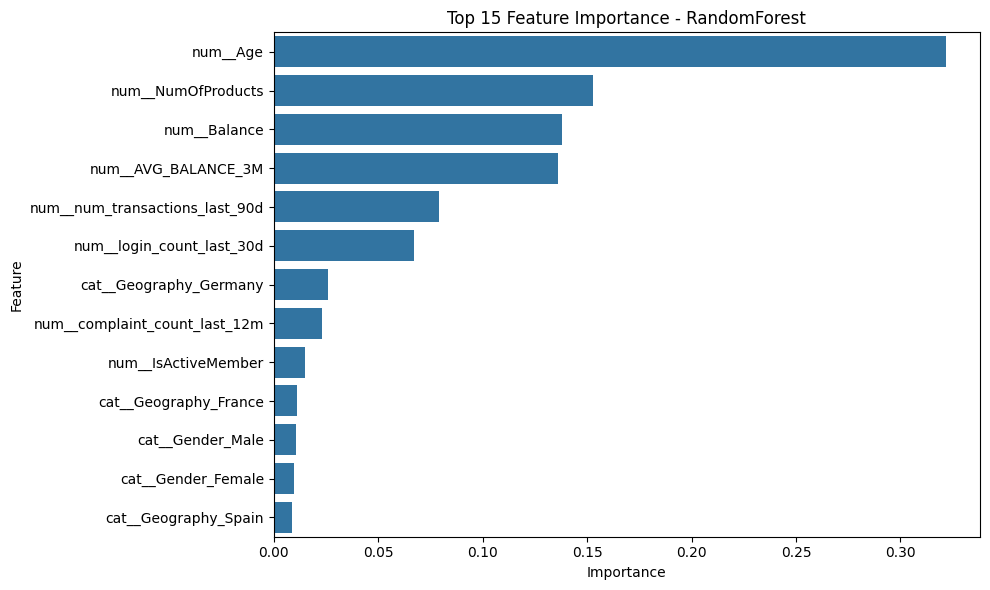

In [10]:
# ====================== 6. FEATURE IMPORTANCE ======================
if hasattr(best_pipe.named_steps['classifier'], 'feature_importances_'):
    selected_features = best_pipe.named_steps['feature_selection'].get_support()
    preprocessed_features = best_pipe.named_steps['preprocessor'].get_feature_names_out()
    selected_feature_names = preprocessed_features[selected_features]
    
    importances = best_pipe.named_steps['classifier'].feature_importances_
    feat_imp = pd.DataFrame({'Feature': selected_feature_names, 'Importance': importances}) \
                .sort_values('Importance', ascending=False)
    
    print("\nTop 15 Feature Importance:")
    print(feat_imp.head(15))
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
    plt.title(f"Top 15 Feature Importance - {best_model}")
    plt.tight_layout()
    plt.show()

In [11]:
import joblib

# Lưu mô hình tốt nhất
joblib.dump(best_pipe, "models/best_model.pkl")

# Lưu preprocessor (bộ tiền xử lý)
joblib.dump(best_pipe.named_steps['preprocessor'], "models/preprocessor.pkl")

# Lưu ngưỡng tối ưu (ví dụ chọn threshold theo Youden’s J hoặc F1)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
joblib.dump(optimal_threshold, "models/optimal_threshold.pkl")

# Lưu feature importance nếu có
if hasattr(best_pipe.named_steps['classifier'], 'feature_importances_'):
    selected_features = best_pipe.named_steps['feature_selection'].get_support()
    preprocessed_features = best_pipe.named_steps['preprocessor'].get_feature_names_out()
    selected_feature_names = preprocessed_features[selected_features]
    importances = best_pipe.named_steps['classifier'].feature_importances_
    feat_imp = pd.DataFrame({'Feature': selected_feature_names, 'Importance': importances}) \
                .sort_values('Importance', ascending=False)
    feat_imp.to_csv("models/feature_importance.csv", index=False)
# Load lại mô hình và preprocessor
loaded_model = joblib.load("models/best_model.pkl")
loaded_preprocessor = joblib.load("models/preprocessor.pkl")
optimal_threshold = joblib.load("models/optimal_threshold.pkl")
print(f"✅ Mô hình, preprocessor và ngưỡng đã được lưu và tải lại thành công!")

✅ Mô hình, preprocessor và ngưỡng đã được lưu và tải lại thành công!
